In [1]:
pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================
# ICU AI SYSTEM — SHAP EXPLAINABILITY
# ============================================

import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries Imported Successfully


In [3]:
# ============================================
# LOAD MODEL + DATA
# ============================================

model = joblib.load(
    "../models/mortality/mortality_xgb_model.pkl"
)

scaler = joblib.load(
    "../models/mortality/mortality_scaler.pkl"
)

feature_columns = joblib.load(
    "../models/mortality/mortality_features.pkl"
)

df = pd.read_csv(
    "../data/processed/mortality_processed.csv"
)

X = df[feature_columns]

print("Model and Data Loaded Successfully")

Model and Data Loaded Successfully


In [4]:
# ============================================
# SCALE FEATURES
# ============================================

X_scaled = scaler.transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [5]:
# ============================================
# CREATE SHAP EXPLAINER
# ============================================

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_scaled)

print("SHAP Values Generated")

SHAP Values Generated


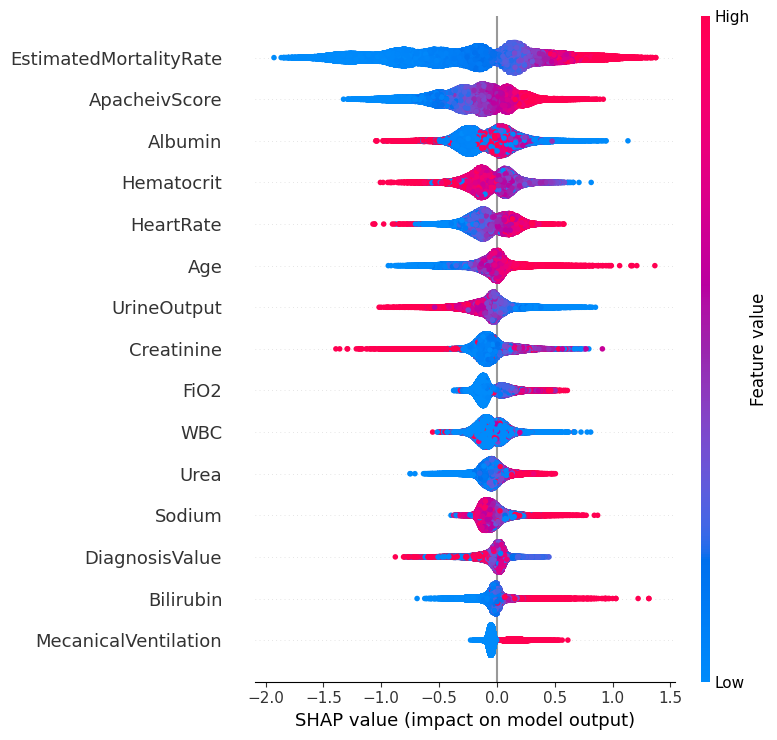

In [6]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    X,
    max_display=15
)

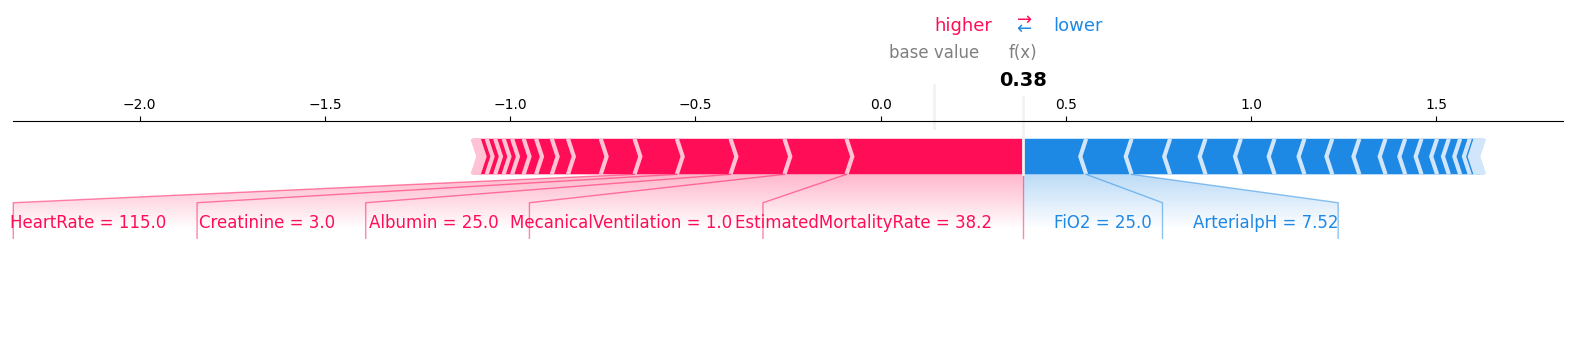

In [7]:
# ============================================
# EXPLAIN SINGLE PATIENT
# ============================================

patient_index = 10

shap.force_plot(

    explainer.expected_value,

    shap_values[patient_index],

    X.iloc[patient_index],

    matplotlib=True
)